## About the analysis


In [1]:
diag_name = "atw_atmos_ts_monthly_sfc_ocean"
diag_desc = "Annual-mean climatological diagnostics"
diag_lead_author = "Andrew Wittenberg"
contributors = ["Soelem Bhuiyan", "Aparna Radhakrishnan"]

more_info = """
================================================================================
INPUT REQUIREMENTS & DOCUMENTATION
================================================================================
This script evaluates climatological biases by comparing high-resolution climate 
model outputs against observational datasets. It regrids the model to the obs 
grid using bilinear interpolation after applying a native land mask.

Required Input Data:
  1. Model Data: Monthly time-series NetCDF files (e.g., atmos.*.t_surf.nc).
  2. Obs Data: Monthly observational NetCDF file (e.g., OISST).
  3. Static File: Model grid specification file (atmos.static.nc) containing 
                  the 'land_mask' variable.
================================================================================
"""

## Jupyter Notebook Workflow Outline

The analysis is built upon the following procedures:

---

### <a id="section1"></a>Section 1: Prepare Diagnostics Settings
- Set the parameters  
- Set the runtime configurations  

---

### <a id="section2"></a>Section 2: Load Data from Catalog Files
Two tested options available (users can override with documentation):
- Intake-ESM option  
This section also handles retrieving files from TAPE file using dmget utility

---

### <a id="section3"></a>Section 3: Diagnostics Computation
- Step 1. Compute climatology  
- Step 2. Apply land masking  
- Step 3. Regrid  
- Step 4. Spatial slicing  
- Step 5. Statistics computation  

---

### <a id="section4"></a>Section 4: Results Visualization
- Plot specifications  
- Surface temperature bias maps (SPEAR-HI vs OISST)  

---

### <a id="section5"></a>Section 5: Citations and More About this Diagnostics
- TBA


## Section 1: Prepare Diagnostics Setup 

In [2]:
import xarray as xr
import numpy as np
import xesmf as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import time
import os
import sys
import logging

# 1. Standardize the Path 
# If we can't find 'diagnostics', we add the parent directory to sys.path
try:
    import diagnostics
except ImportError:
    parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
    if parent_dir not in sys.path:
        sys.path.append(parent_dir)

# 2. Unified Imports
try:
    # Attempt absolute imports (Standard for Project Root/Pipelines)
    from diagnostics.utils import dhelper, dmget
    from diagnostics.utils.logger import init_logger  # Assuming location based on your snippet
    from diagnostics.utils.dhelper import load_settings, dict_to_settings
except ModuleNotFoundError:
    # Fallback to relative/local imports (Standard for Interactive/Subfolder)
    from utils import dhelper, dmget, logger
    from utils.dhelper import load_settings, dict_to_settings
    from utils.logger import init_logger

init_logger(f"{diag_name}_analysis.log",level=logging.DEBUG) #TODO use analysis script name as prefix for log file name.
logger = logging.getLogger(__name__) # Things we could do if we know the debug level INFO DEBUG WARNING ERROR CRITICAL
logging.info(f"Analysis log is written to {diag_name}_analysis.log")
t0 = time.perf_counter() if logger.isEnabledFor(logging.INFO) else None #track time if DEBUG, otherwise set to None to avoid unnecessary perf_counter calls

# Silence the xarray warnings about future updates
xr.set_options(use_new_combine_kwarg_defaults=True)


11:28:21: Analysis log is written to atw_atmos_ts_monthly_sfc_ocean_analysis.log


## General settings

In [8]:
#If the mode is `interactive`, the user will manually input the needed info of the POD options, otherwise the info will be read from the default `settings.jsonc` file and the [analysis_script]_config.json
# Define a mode 
mode = "interactive"

## Diagnostics settings

##### The following simply helps us load the settings and config files and return the variables in an intuitive batch-friendly way
##### Refer to settings.json and atw_atmos_ts_monthly_sfc_ocean_updated_config.json in diagnostics directory

In [4]:
if( mode != "interactive"):
    # 1. Load and convert in one line
    case_info = dhelper.load_settings("atw_atmos_ts_monthly_sfc_ocean_updated_config.json")  #case_info
    sd = dhelper.load_settings("settings.json")

    # 2. Extract your favorite handles
    dimensions = sd.dimensions
    settings = sd.settings
    varlist = sd.varlist

### **Quick Reference: Configuration Variables**

| Prefix | Source File | Description | Code Example |
| :--- | :--- | :--- | :--- |
| **`case_info`** | `case_info.json` | **Paths/System:** File locations and directories. | `case_info.DATA_CATALOG` `case_info.OBS_FILE_PATH`|
| **`case_info.case_list`** | `case_info.json` | **Model Info:** Case metadata (e.g., `SPEAR_HI_8`). | `case_info.case_list.SPEAR_HI_8.enddate` |
| **`dimensions`** | `settings.json` | **Slicing:** Coordinate bounds (lat, lon, time). | `slice(*dimensions.lat.LAT_BOUNDS)` |
| **`varlist`** | `settings.json` | **Variables:** Variable names and unit offsets. | `varlist.t_surf.MODEL_OFFSET` |
| **`settings`** | `settings.json` | **Plotting:** Titles, labels, and contour levels. | `levels=settings.SST_SHADE_LEVELS` |

In [24]:
#These are the runtime configuration values.
#For e.g. which experiments to run diagnostis on, where the data is located, etc. 
#If you're not running this interactively, these values will be overridden by the atw_atmos_ts_monthly_sfc_ocean_updated_config.json file. 
# If you are running this interactively, these values will be used instead of the json file.
if mode == "interactive":
    print("Applying Interactive case settings...")
    
    # 1. Define the dictionary to match the JSON structure exactly
    case_info_dict = {
        "pod_list": [
            "atw_atmos_ts_monthly_sfc_ocean_updated"
        ],
        "case_list": {
            "SPEAR-HI_8": {
                "convention": "GFDL",
                "enddate": "03981231000000",
                "model": "SPEAR_HI_8",
                "startdate": "00010101000000",
                "frequency": "mon",
                "static_vars": ["land_mask", "frac_ocean"]
            }
        },
        "DATA_CATALOG": "/home/a1r/git/atw/atw_diags/cats/ciheim/48-SPEAR-cat.json",
        "OBS_DATA_ROOT": "/home/atw/data/reynolds/v2/noaa.oisst.v2/",
        "OBS_FILE_PATH": "/home/atw/data/reynolds/v2/noaa.oisst.v2/sst_janstart.nc",
        "WORK_DIR": "/home/a1r/git/atw/atw_diags/outputs/",
        "OUTPUT_DIR": "/home/a1r/git/atw/atw_diags/outputs/"
    }

    # 2. Convert to Namespace for dot notation
    case_info = dict_to_settings(case_info_dict)

Applying Interactive case settings...


In [ ]:
# ==============================================================================
# SETTINGS  These normally do not get changed by the user. 
#Plot settings, variable settings, dimension settings, etc. that are specific for the diagnostic script are mentioned here.
# These are settings that are used by the diagnostic script. They can be overridden by the user when running in interactive mode, 
# but they are not expected to be changed by the user. Use the settings.json file in the diagnostics directory to set these values for the interactive mode. 
# The settings in the settings.json file will override the default settings defined here if you don't run in interactive mode. 
# If you run in interactive mode, the settings in the settings.json file will be ignored and the settings defined here will be used instead.
# ==============================================================================
if (mode) == "interactive":
    print("Interactive settings")
    settings = {
        "settings": {
        "description": "SPEAR Model vs OISST Surface Temperature Analysis",
        "driver": "atw_atmos_ts_monthly_sfc_ocean.py",
        "long_name": "Monthly Surface Temperature Diagnostics",
        "convention": "GFDL",
        "PLOT_TITLE_MODEL": "SPEAR Model (Years 0001-0100)",
        "PLOT_TITLE_OBS": "OISST Observations (1982-2016)",
        "CBAR_LABEL": "SST (°C)",
        "SST_LINE_LEVELS": [
            16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33
        ],
        "SST_SHADE_LEVELS": [
            16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 
            21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 
            27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0, 30.5, 31.0, 31.5, 32.0, 
            32.5, 33.0
        ],
        "BIAS_LINE_LEVELS": [-5, 5.5, 0.5],
        "BIAS_TICK_INTERVAL": [-5, 6, 1],
        "BIAS_SHADE_LEVELS": [
            -5.0, -4.75, -4.5, -4.25, -4.0, -3.75, -3.5, -3.25, -3.0, -2.75, 
            -2.5, -2.25, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 
            0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 
            3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0
        ]
    },
    "dimensions": {
        "lat": {
            "standard_name": "latitude",
            "axis": "Y",
            "LAT_BOUNDS": [-20, 20]
        },
        "lon": {
            "standard_name": "longitude",
            "axis": "X",
            "LON_BOUNDS": [25, 385]
        },
        "time": {
            "standard_name": "time",
            "MODEL_TIME_SLICE": [0, 1200],
            "OBS_TIME_SLICE": ["1982", "2016"]
        }
    },
    "varlist": {
        "vars": {
            "freq": "mon",
            "realm": "atmos",
            "chunk_freq": "10yr",
            "MODEL_VAR": "t_surf",
            "OBS_VAR": "SST",
            "MODEL_OFFSET": -273.15,
            "dimensions": ["time", "lat", "lon"]
        },
        "STATIC_VARS": {
            "freq": "fx",
            "realm": "atmos",
            "STATIC_VARS": ["land_mask", "frac_ocean"],
            "dimensions": ["lat", "lon"]
        }
    }
    }

    # Convert the settings dictionary into an object so values can be accessed
    # using dot notation instead of dictionary keys (e.g., settings.OBS_PATH)
    settings_ns = dhelper.dict_to_settings(settings)
    case_info_ns = dhelper.dict_to_settings(case_info)
    # Extract your favorite handles
    dimensions = settings_ns.dimensions
    settings = settings_ns.settings
    varlist = settings_ns.varlist


Interactive settings
namespace(SPEAR-HI_8=namespace(convention='GFDL', enddate='03981231000000', model='SPEAR_HI_8', startdate='00010101000000', frequency='mon', static_vars=['land_mask', 'frac_ocean']))


In [17]:
#Time section
if t0 is not None:
    logger.debug(f"Section 1 Process completed in {time.perf_counter() - t0:.4f} seconds")

11:31:46: Section 1 Process completed in 204.8843 seconds


## Section 2 Loading Data from Catalogs
lets figure out ds_model with catalogs

In [18]:
#TODO handle time and profiling better

t02 = time.perf_counter()
import intake, intake_esm

11:31:50: Registering codec 'zlib'
11:31:50: Registering codec 'gzip'
11:31:50: Registering codec 'bz2'
11:31:50: Registering codec 'lzma'
11:31:50: Registering codec 'blosc'
11:31:50: Registering codec 'zstd'
11:31:50: Registering codec 'lz4'
11:31:50: Registering codec 'astype'
11:31:50: Registering codec 'delta'
11:31:50: Registering codec 'quantize'
11:31:50: Registering codec 'fixedscaleoffset'
11:31:50: Registering codec 'packbits'
11:31:50: Registering codec 'categorize'
11:31:50: Registering codec 'pickle'
11:31:50: Registering codec 'base64'
11:31:50: Registering codec 'shuffle'
11:31:50: Registering codec 'bitround'
11:31:50: Registering codec 'crc32'
11:31:50: Registering codec 'adler32'
11:31:50: Registering codec 'jenkins_lookup3'
11:31:50: Registering codec 'json2'
11:31:50: Registering codec 'vlen-utf8'
11:31:50: Registering codec 'vlen-bytes'
11:31:50: Registering codec 'vlen-array'
11:31:50: Registering codec 'fletcher32'
11:31:50: Registering codec 'msgpack2'
11:31:50

In [25]:
cat = intake.open_esm_datastore(case_info.DATA_CATALOG)

#Exception - TODO to be addressed at the catalog level
df = cat.df 
df['table_id'] = df['table_id'].fillna('NA')
df['table_id'].value_counts(dropna=False)

cat_subset = cat.search(
    variable_id=varlist.vars.MODEL_VAR,
    frequency=varlist.vars.freq,
    realm=varlist.vars.realm,
    chunk_freq=varlist.vars.chunk_freq,
    cell_methods="ts", 
)

11:35:03: open file: /home/a1r/git/atw/atw_diags/cats/ciheim/48-SPEAR-cat.json
11:35:03: open file: /home/Ciheim.Brown/48-SPEAR-cat.csv


In [26]:
cat_subset

,unique
activity_id,1
institution_id,1
source_id,1
experiment_id,1
frequency,1
realm,1
table_id,1
member_id,1
grid_label,1
variable_id,1


In [27]:
#dmgets the files before we proceed
#TODO check if the filesystem is TAPE or not

try:
    # Works when running from the Project Root (e.g., Snakemake/Papermill)
    from diagnostics.utils import dmget
except ModuleNotFoundError:
    try:
        # Works when running interactively from inside the 'diagnostics' folder
        from utils import dmget
    except ModuleNotFoundError:
        # Fallback: add the path manually if both fail
        import sys
        import os
        sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
        from diagnostics.utils import dmget

#from diagnostics.utils import dmget
logging.info("Dmgetting files...")
dmstatus = cat_subset.df["path"].apply(dmget.dmgetmagic)
logging.info("done")

11:35:17: Dmgetting files...
11:35:28: done


In [28]:
dset_dict = cat_subset.to_dataset_dict(
    xarray_open_kwargs={"decode_times": True,"chunks": {}}
)
dset_dict.keys()
logging.info("to_dataset_dict complete")


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id.experiment_id.frequency.table_id.realm.chunk_freq'


<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

11:35:30: open file: /archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/ts/monthly/10yr/atmos.027101-028012.t_surf.nc
11:35:30: open file: /archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/ts/monthly/10yr/atmos.016101-017012.t_surf.nc
11:35:30: open file: /archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/ts/monthly/10yr/atmos.014101-015012.t_surf.nc
11:35:30: open file: /archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/ts/monthly/10yr/atmos.002101-003012.t_surf.nc
11:35:30: open file: /archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/ts/monthly/10yr/atmos.004101-005012.t_surf.nc
11:35:30: open file: /archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/ts/monthly/10yr/atmos.000101-001012.t_surf.nc
11:35:30: open file: /archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/ts/monthly/10yr/atmos.026101-027012.t_surf.nc
11:35:30: ope

In [30]:
#TODO don't hardcode this, sanity check dset_dict and retrieve from that with index
ds_model = dset_dict['SPEAR_HI_8.SPEAR_c384_OM4p08_Control_1990_A13.mon.NA.atmos.10yr']

In [31]:
ds_model

<xarray.Dataset> Size: 16GB
Dimensions:    (time: 4680, lat: 720, lon: 1152, bnds: 2)
Coordinates:
  * time       (time) object 37kB 0001-01-16 12:00:00 ... 0390-12-16 12:00:00
  * lat        (lat) float64 6kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon        (lon) float64 9kB 0.1562 0.4687 0.7812 ... 359.2 359.5 359.8
  * bnds       (bnds) float64 16B 1.0 2.0
    lat_bnds   (lat, bnds) float64 12kB dask.array<chunksize=(720, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 18kB dask.array<chunksize=(1152, 2), meta=np.ndarray>
    time_bnds  (time, bnds) object 75kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Data variables:
    t_surf     (time, lat, lon) float32 16GB dask.array<chunksize=(120, 720, 1152), meta=np.ndarray>
Attributes: (12/20)
    NumFilesInSet:                   1
    title:                           SPEAR_c384_OM4p08_Control_1990_A13
    grid_type:                       regular
    grid_tile:                       N/A
    fre-nctools:                     FRE NCTools version 2024.05 (git: 2024.0...
    code_release_version:            2024.05
    ...                              ...
    intake_esm_attrs:variable_id:    t_surf
    intake_esm_attrs:chunk_freq:     10yr
    intake_esm_attrs:cell_methods:   ts
    intake_esm_attrs:standard_name:  surface_temperature
    intake_esm_attrs:_data_format_:  netcdf
    intake_esm_dataset_key:          SPEAR_HI_8.SPEAR_c384_OM4p08_Control_199...

In [32]:
# ==========================================
# 1A. LOAD DATA
# ==========================================
logging.info("[1/7] Loading data...")

ds_model = ds_model.isel(time=dimensions.time.MODEL_TIME_SLICE)



11:36:33: [1/7] Loading data...


In [33]:

# ==========================================
# 1B. LOAD OBS DATA
# ==========================================

ds_obs = xr.open_dataset(case_info.OBS_FILE_PATH) #orig OBS_PATH

11:36:35: Registering codec 'fill_hdf_strings'
11:36:35: Registering codec 'grib'
11:36:35: Registering codec 'FITSAscii'
11:36:35: Registering codec 'FITSVarBintable'


In [34]:

# ==========================================
# 1C. LOAD STATIC DATA
# ==========================================

#"STATIC_VARS": ["land_mask","frac_ocean"]

cat_subset = cat.search(
    variable_id="fixed",
    frequency=varlist.STATIC_VARS.freq,
    realm=varlist.STATIC_VARS.realm,
    table_id = varlist.STATIC_VARS.freq, #fx stands for fixed variables, which includes static variables like land_mask and frac_ocean
)
dset_dict_static = cat_subset.to_dataset_dict(
    xarray_open_kwargs={"decode_times": True,"chunks": {}}
)
dset_dict_static.keys()
ds_static = dset_dict_static['SPEAR_HI_8.SPEAR_c384_OM4p08_Control_1990_A13.fx.fx.atmos']


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id.experiment_id.frequency.table_id.realm'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:00&lt;00:00]</div>

11:36:36: open file: /archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/atmos.static.nc


In [35]:
if t02 is not None: logger.debug(f"Step 2 : {time.perf_counter() - t02:.4f}s"); t02 = time.perf_counter()

11:36:38: Step 2 : 289.0797s


## Section 3 Diagnostics Computation

###1. Computing Climatology

In [36]:
# ==========================================
# 2. COMPUTING CLIMATOLOGY
# ==========================================
logging.info("[2/7] Computing climatologies...") #TODO redo the numbering of the steps in the logging messages
t0 = time.perf_counter()

model_clim = ds_model[varlist.vars.MODEL_VAR].mean(dim='time', keep_attrs=True)
model_clim = model_clim + varlist.vars.MODEL_OFFSET 
obs_clim = ds_obs[varlist.vars.OBS_VAR].sel(time=slice(*dimensions.time.OBS_TIME_SLICE)).mean(dim='time', keep_attrs=True)

model_clim = model_clim.compute()
obs_clim = obs_clim.compute()


11:36:44: [2/7] Computing climatologies...


####2.Apply Land Masking

In [37]:
# ==========================================
# 3. NATIVE LAND MASK
# ==========================================
logging.info("[3/7] Applying native model land mask...")

try:
    ds_static # = xr.open_dataset(settings.STATIC_PATH)
    if 'land_mask' in ds_static:
        model_clim = model_clim.where(ds_static['land_mask'] < 0.5)
    elif 'frac_ocean' in ds_static:
        model_clim = model_clim.where(ds_static['frac_ocean'] > 0.5)
    else:
        print("WARNING: 'land_mask' or 'frac_ocean' not found in static file. Land bleed may occur.")
except FileNotFoundError:
    print(f"WARNING: Could not find {settings.STATIC_PATH}. Land bleed will occur!")


11:36:52: [3/7] Applying native model land mask...


####3. Regridding

In [38]:
# ==========================================
# 4. REGRIDDING
# ==========================================

logging.info("[4/7] Evaluating grids and regridding Model to Obs...")
t0 = time.perf_counter()

# 1. Calculate the resolution (total pixels) of each grid
source_pixels = model_clim.lat.size * model_clim.lon.size
target_pixels = obs_clim.lat.size * obs_clim.lon.size

# 2. The Switch Logic (Replicating Andrew's def_regrid_ax_str.jnl)
if source_pixels > target_pixels:
    regrid_method = 'conservative' # Equivalent to Ferret's @ave
    logger.info("-> High-to-Low resolution detected. Switch = 1 (CONSERVATIVE)")
else:
    regrid_method = 'bilinear'     # Equivalent to Ferret's @lin
    logger.info("-> Low-to-High resolution detected. Switch = 0 (BILINEAR)")

# 3. Execute the regridding using the auto-selected method
regridder = xe.Regridder(model_clim, obs_clim, regrid_method, periodic=True)
model_regridded = regridder(model_clim)


11:36:53: [4/7] Evaluating grids and regridding Model to Obs...
11:36:53: -> High-to-Low resolution detected. Switch = 1 (CONSERVATIVE)


/nbhome/Aparna.Radhakrishnan/conda/envs/spear-analysis/lib/python3.14/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/nbhome/Aparna.Radhakrishnan/conda/envs/spear-analysis/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


11:37:15: Loading extension: EntryPoint(name='init', value='sparse.numba_backend._numba_extension:_init_extension', group='numba_extensions')
11:37:15: bytecode dump:
>          0	NOP(arg=None, lineno=398)
           2	RESUME(arg=0, lineno=398)
           4	LOAD_GLOBAL(arg=0, lineno=455)
          14	LOAD_ATTR(arg=2, lineno=455)
          34	LOAD_ATTR(arg=4, lineno=455)
          54	LOAD_ATTR(arg=7, lineno=455)
          74	LOAD_GLOBAL(arg=0, lineno=455)
          84	LOAD_ATTR(arg=8, lineno=455)
         104	LOAD_ATTR(arg=10, lineno=455)
         124	CALL(arg=1, lineno=455)
         132	STORE_FAST(arg=2, lineno=455)
         134	LOAD_FAST_BORROW(arg=2, lineno=456)
         136	LOAD_ATTR(arg=13, lineno=456)
         156	LOAD_SMALL_INT(arg=0, lineno=456)
         158	CALL(arg=1, lineno=456)
         166	POP_TOP(arg=None, lineno=456)
         168	LOAD_GLOBAL(arg=0, lineno=457)
         178	LOAD_ATTR(arg=2, lineno=457)
         198	LOAD_ATTR(arg=4, lineno=457)
         218	LOAD_ATTR(arg=7,

####4. Spatial Slicing

In [39]:
# ==========================================
# 5. SPATIAL SLICING & MASKING
# ==========================================
logging.info("[5/7] Isolating spatial domain and applying common mask...")

model_domain = model_regridded.sel(lat=slice(dimensions.lat.LAT_BOUNDS[0], dimensions.lat.LAT_BOUNDS[1]))
obs_domain = obs_clim.sel(lat=slice(dimensions.lat.LAT_BOUNDS[0], dimensions.lat.LAT_BOUNDS[1]))

common_mask = model_domain.notnull() & obs_domain.notnull()

a_var = obs_domain.where(common_mask)   # Ferret Variable A (Obs)
b_var = model_domain.where(common_mask) # Ferret Variable B (Model)
bma_var = b_var - a_var                 # Ferret Bias (Model minus Obs)



11:37:25: [5/7] Isolating spatial domain and applying common mask...


####5. Statistics Computation

In [40]:
# ==========================================
# 6. SPHERICAL STATISTICS (Cosine Weighting)
# ==========================================
logging.info("[6/7] Calculating spherically-weighted statistics...")

weights = np.cos(np.deg2rad(a_var.lat))
weights.name = "weights"

def get_weighted_stats(da, w):
    daw = da.weighted(w)
    ave = daw.mean(skipna=True).values
    std = daw.std(skipna=True).values
    vmax = da.max(skipna=True).values
    vmin = da.min(skipna=True).values
    return ave, std, vmax, vmin

a_ave, a_std, a_max, a_min = get_weighted_stats(a_var, weights)
b_ave, b_std, b_max, b_min = get_weighted_stats(b_var, weights)
bma_ave, bma_std, bma_max, bma_min = get_weighted_stats(bma_var, weights)

ab_rmsd = np.sqrt(((bma_var)**2).weighted(weights).mean(skipna=True)).values
covar = ((b_var - b_ave) * (a_var - a_ave)).weighted(weights).mean(skipna=True)
ab_corr = (covar / (b_var.weighted(weights).std(skipna=True) * a_var.weighted(weights).std(skipna=True))).values

logger.info(f"Stats Check -> Bias Ave: {bma_ave:.3f}, RMSD: {ab_rmsd:.3f}, Corr: {ab_corr:.2f}")

if t02 is not None: logger.debug(f"Section 3 : {time.perf_counter() - t02:.4f}s"); t02 = time.perf_counter()

11:37:28: [6/7] Calculating spherically-weighted statistics...
11:37:28: bytecode dump:
>          0	NOP(arg=None, lineno=1079)
           2	COPY_FREE_VARS(arg=1, lineno=1079)
           4	RESUME(arg=0, lineno=1079)
           6	LOAD_GLOBAL(arg=0, lineno=1094)
          16	LOAD_ATTR(arg=2, lineno=1094)
          36	PUSH_NULL(arg=None, lineno=1094)
          38	LOAD_FAST_BORROW(arg=3, lineno=1094)
          40	LOAD_DEREF(arg=8, lineno=1094)
          42	LOAD_CONST(arg=1, lineno=1094)
          44	CALL_KW(arg=2, lineno=1094)
          52	STORE_FAST(arg=4, lineno=1094)
          54	LOAD_GLOBAL(arg=5, lineno=1096)
          64	LOAD_FAST_BORROW(arg=3, lineno=1096)
          66	LOAD_SMALL_INT(arg=0, lineno=1096)
          68	BINARY_OP(arg=26, lineno=1096)
          80	CALL(arg=1, lineno=1096)
          88	GET_ITER(arg=None, lineno=1096)
>         90	FOR_ITER(arg=93, lineno=1096)
          94	STORE_FAST(arg=5, lineno=1096)
          96	LOAD_GLOBAL(arg=5, lineno=1097)
         106	LOAD_GLOBAL(

## Section 4 Results Visualization

11:37:30: [7/7] Plotting data...
11:37:30: Loaded backend module://matplotlib_inline.backend_inline version unknown.
11:37:30: Loaded backend module://matplotlib_inline.backend_inline version unknown.
11:37:30: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
11:37:30: findfont: score(FontEntry(fname='/nbhome/Aparna.Radhakrishnan/conda/envs/spear-analysis/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/cmtt10.ttf', name='cmtt10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
11:37:30: findfont: score(FontEntry(fname='/nbhome/Aparna.Radhakrishnan/conda/envs/spear-analysis/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/cmss10.ttf', name='cmss10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
11:37:30: findfont: score(FontEntry(fname='/nbhome/Aparna.Radhakrishnan/conda/envs/spear-analysis/lib/python3.14/site-packages/matplotlib/mp

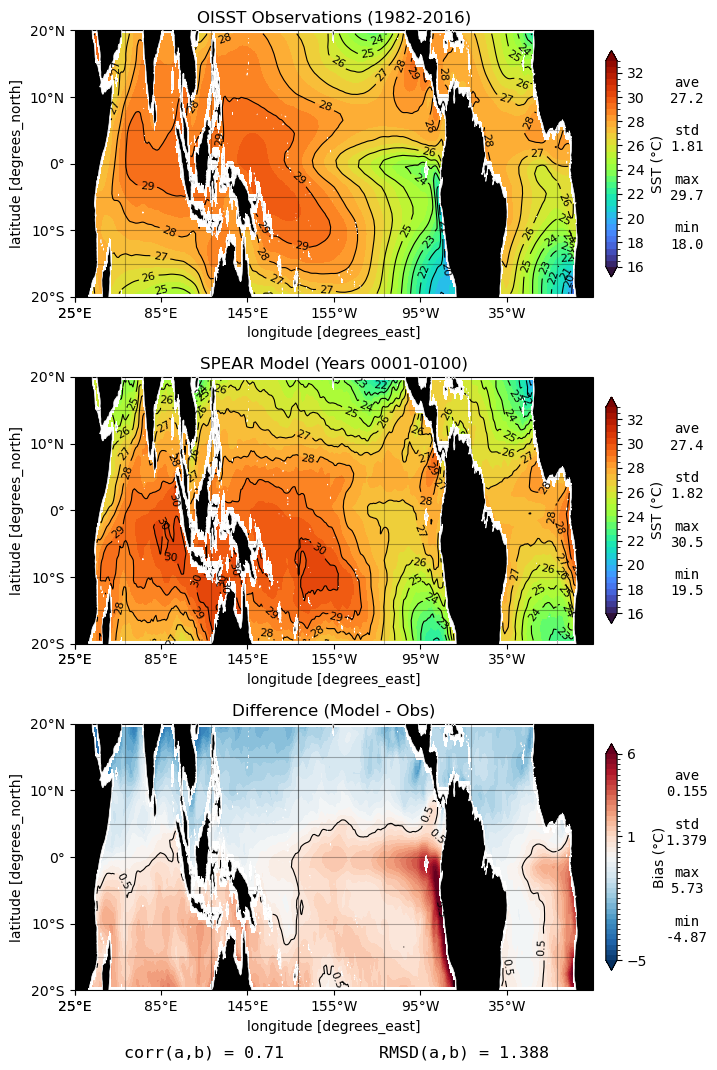

11:37:38: Section 4 : 7.3409s
11:37:38: TOTAL TIME: 44.4820s


In [41]:
# ==========================================
# 7. EXECUTION & PLOTTING 
# ==========================================
logging.info("[7/7] Plotting data...")

fig, axes = plt.subplots(3, 1, figsize=(10, 12), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=205)})

plt.subplots_adjust(right=0.75, bottom=0.08, hspace=0.3)

for ax in axes:
    ax.set_extent([dimensions.lon.LON_BOUNDS[0], dimensions.lon.LON_BOUNDS[1], dimensions.lat.LAT_BOUNDS[0], dimensions.lat.LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
    ax.set_aspect('auto', adjustable='box')
    ax.add_feature(cfeature.LAND, facecolor='black', zorder=2)
    ax.coastlines(color='white', linewidth=0.5, zorder=3)
    ax.set_xticks(np.arange(dimensions.lon.LON_BOUNDS[0], dimensions.lon.LON_BOUNDS[1]+1, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(dimensions.lat.LAT_BOUNDS[0], dimensions.lat.LAT_BOUNDS[1]+1, 10), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.gridlines(color='black', linestyle='-', alpha=0.3, zorder=4)

# --- Panel 1: Obs ---
cs1 = a_var.plot.contourf(ax=axes[0], transform=ccrs.PlateCarree(), levels=settings.SST_SHADE_LEVELS, cmap='turbo', add_colorbar=False, extend='both')
line1 = a_var.plot.contour(ax=axes[0], transform=ccrs.PlateCarree(), levels=settings.SST_LINE_LEVELS, colors='black', linewidths=0.8)
axes[0].clabel(line1, inline=True, fontsize=8, fmt='%1.0f')
axes[0].set_title(settings.PLOT_TITLE_OBS)
fig.colorbar(cs1, ax=axes[0], label=settings.CBAR_LABEL, pad=0.02, shrink=0.85)

axes[0].text(1.18, 0.5, f"ave\n{a_ave:.1f}\n\nstd\n{a_std:.2f}\n\nmax\n{a_max:.1f}\n\nmin\n{a_min:.1f}", 
             transform=axes[0].transAxes, va='center', ha='center', fontsize=10, family='monospace', clip_on=False)

# --- Panel 2: Model ---
cs2 = b_var.plot.contourf(ax=axes[1], transform=ccrs.PlateCarree(), levels=settings.SST_SHADE_LEVELS, cmap='turbo', add_colorbar=False, extend='both')
line2 = b_var.plot.contour(ax=axes[1], transform=ccrs.PlateCarree(), levels=settings.SST_LINE_LEVELS, colors='black', linewidths=0.8)
axes[1].clabel(line2, inline=True, fontsize=8, fmt='%1.0f')
axes[1].set_title(settings.PLOT_TITLE_MODEL)
fig.colorbar(cs2, ax=axes[1], label=settings.CBAR_LABEL, pad=0.02, shrink=0.85)

axes[1].text(1.18, 0.5, f"ave\n{b_ave:.1f}\n\nstd\n{b_std:.2f}\n\nmax\n{b_max:.1f}\n\nmin\n{b_min:.1f}", 
             transform=axes[1].transAxes, va='center', ha='center', fontsize=10, family='monospace', clip_on=False)

# --- Panel 3: Bias ---
cs3 = bma_var.plot.contourf(ax=axes[2], transform=ccrs.PlateCarree(), levels=settings.BIAS_SHADE_LEVELS, cmap='RdBu_r', add_colorbar=False, extend='both')
line_widths = [1.5 if lev == 0 else 0.8 for lev in settings.BIAS_LINE_LEVELS]
line3 = bma_var.plot.contour(ax=axes[2], transform=ccrs.PlateCarree(), levels=settings.BIAS_LINE_LEVELS, colors='black', linewidths=line_widths)
axes[2].clabel(line3, inline=True, fontsize=8, fmt='%1.1f')
axes[2].set_title("Difference (Model - Obs)")
fig.colorbar(cs3, ax=axes[2], label='Bias (°C)', pad=0.02, shrink=0.85, ticks=settings.BIAS_TICK_INTERVAL)

axes[2].text(1.18, 0.5, f"ave\n{bma_ave:.3f}\n\nstd\n{bma_std:.3f}\n\nmax\n{bma_max:.2f}\n\nmin\n{bma_min:.2f}", 
             transform=axes[2].transAxes, va='center', ha='center', fontsize=10, family='monospace', clip_on=False)

axes[2].text(0.25, -0.25, f"corr(a,b) = {ab_corr:.2f}", transform=axes[2].transAxes, ha='center', fontsize=12, family='monospace', clip_on=False)
axes[2].text(0.75, -0.25, f"RMSD(a,b) = {ab_rmsd:.3f}", transform=axes[2].transAxes, ha='center', fontsize=12, family='monospace', clip_on=False)

# Save Figure
plt.savefig(case_info.OUTPUT_DIR + "t_surf_final_replica.png", dpi=600, bbox_inches='tight')
plt.show()
plt.close()

if t02 is not None: logger.debug(f"Section 4 : {time.perf_counter() - t02:.4f}s"); t02 = time.perf_counter()
if t0 is not None: logger.debug(f"TOTAL TIME: {time.perf_counter() - t0:.4f}s"); t0 = time.perf_counter()
